# Phase Retrieval with Iterative Transform Algorithms

In [22]:
import matplotlib.pyplot as plt
from prysm.mathops import np
from prysm.propagation import focus_dft, prepare_executor

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.polynomials import noll_to_nm, zernike_nm_seq, sum_of_2d_modes

from dygdug.masks import Pupil
np.random.seed(20210425)

## Setting up an optical model

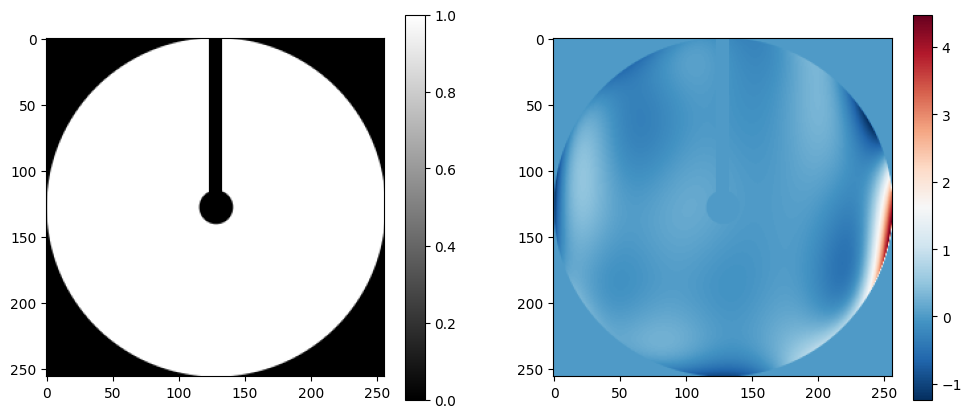

In [151]:
Dpup = 2
Npup = 256
inner_radius = 0.1
outer_radius = 1.0
focal_dx = 10
focal_samples = 128

x, y = make_xy_grid(Npup, diameter=Dpup)
r, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(1, 37)]
basis = list(zernike_nm_seq(nms, r, t))
coeffs = np.random.random(len(basis)) / 10
wfe = sum_of_2d_modes(basis, coeffs)

pupil = Pupil.annular(
    Dpup,
    Npup,
    inner_radius=inner_radius,
    outer_radius=outer_radius
)

bar = np.ones_like(pupil.data)
centerx = 60
centery = 128
widthx = 60
widthy = 5
bar[centerx - widthx: centerx + widthx, centery - widthy: centery + widthy] = 0
pupil.data *= bar

plt.figure(figsize=[12, 5])
plt.subplot(121)
plt.imshow(pupil.data, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(pupil.data * wfe, cmap="RdBu_r")
plt.colorbar()
plt.show()

executor = prepare_executor(
    Dpup / Npup,
    Npup,
    focal_dx,
    focal_samples,
    wavelength=0.5, # um
    efl=100 * Dpup,
)

In [152]:
psf = focus_dft(pupil.data * np.exp(1j * wfe), executor)

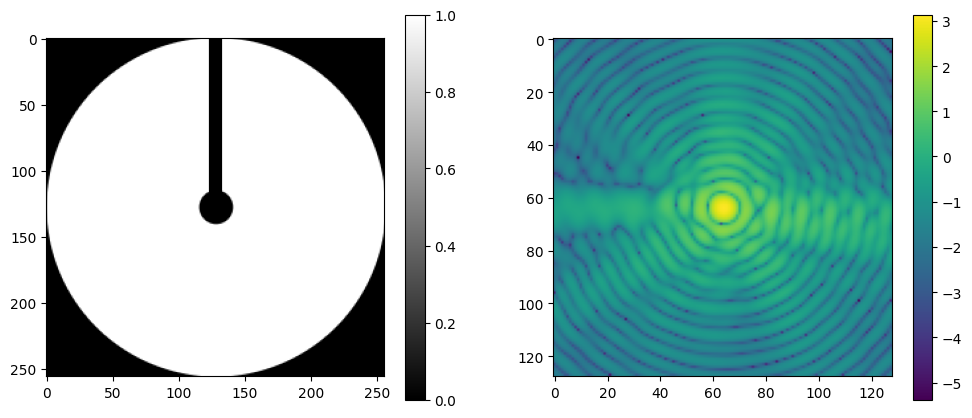

In [153]:
plt.figure(figsize=[12, 5])
plt.subplot(121)
plt.imshow(pupil.data, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(np.log10(np.abs(psf) ** 2))
plt.colorbar()
plt.show()

# Gerchberg-Saxton

In [154]:
from dygdug.phase_retrieval import GerchbergSaxton

gspr = GerchbergSaxton(
    amp=pupil.data,
    wvl=0.5,
    executor=executor,
    data=np.abs(psf) ** 2,
)

In [155]:
N_ITER = 100
for _ in range(N_ITER):
    field_est = gspr.step()
phase_est = np.angle(field_est)

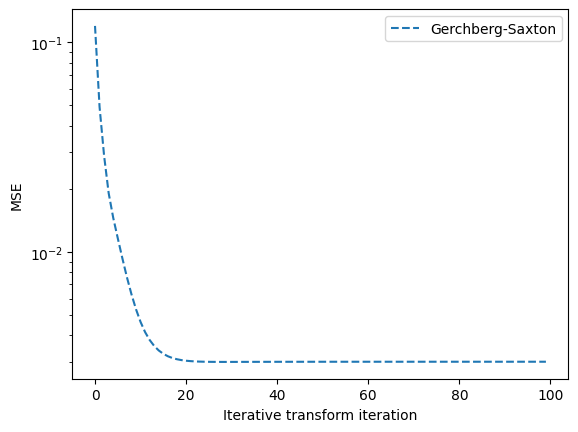

In [156]:
plt.figure()
plt.plot(gspr.cost, linestyle="dashed", label="Gerchberg-Saxton")
plt.ylabel("MSE")
plt.xlabel("Iterative transform iteration")
plt.yscale("log")
plt.legend()
plt.show()

/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)


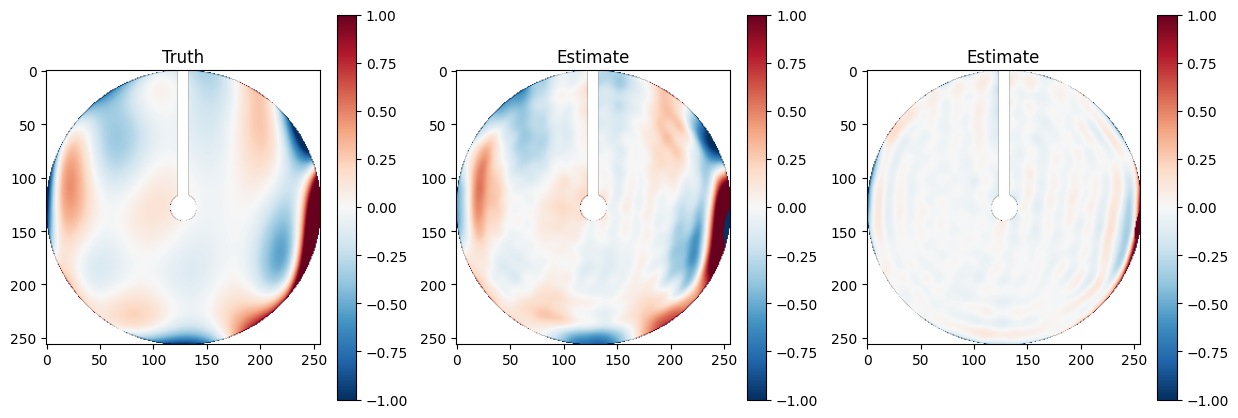

In [157]:
vlim = 1

wfe -= np.mean(wfe[pupil.data==1])
phase_est -= np.mean(phase_est[pupil.data==1])

plt.figure(figsize=[15, 5])
plt.subplot(131)
plt.title("Truth")
plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(132)
plt.title("Estimate")
plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(133)
plt.title("Estimate")
plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

## Error Reduction

In [158]:
from dygdug.phase_retrieval import ErrorReduction 

erpr = ErrorReduction(
    amp=pupil.data,
    wvl=0.5,
    executor=executor,
    data=np.abs(psf) ** 2,
)

for _ in range(N_ITER):
    field_est = erpr.step()
phase_est = np.angle(field_est)

/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)


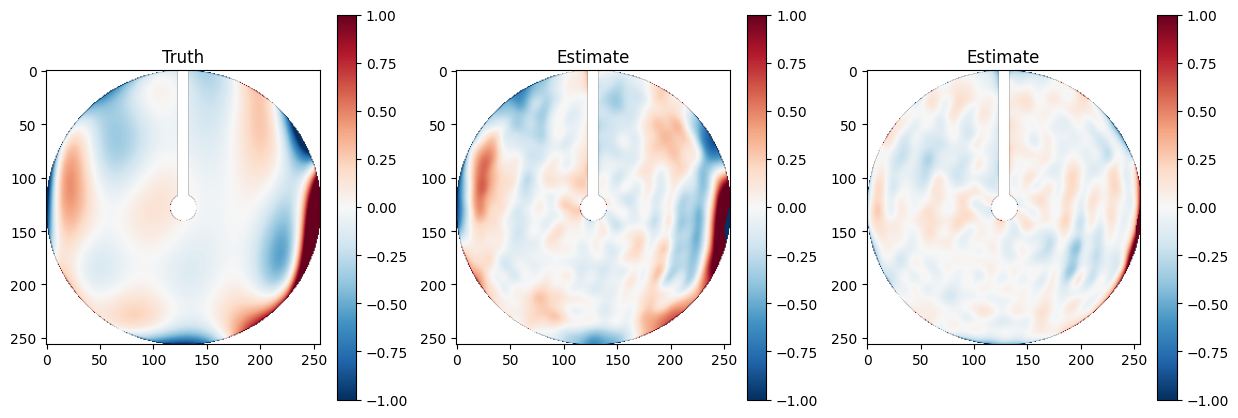

In [159]:
vlim = 1

wfe -= np.mean(wfe[pupil.data==1])
phase_est -= np.mean(phase_est[pupil.data==1])

plt.figure(figsize=[15, 5])
plt.subplot(131)
plt.title("Truth")
plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(132)
plt.title("Estimate")
plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(133)
plt.title("Estimate")
plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

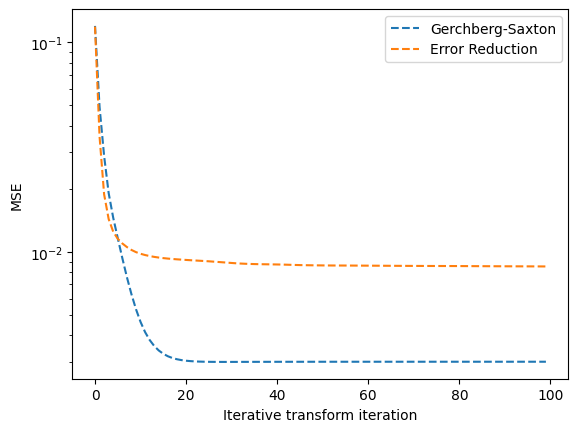

In [160]:
plt.figure()
plt.plot(gspr.cost, linestyle="dashed", label="Gerchberg-Saxton")
plt.plot(erpr.cost, linestyle="dashed", label="Error Reduction")
plt.ylabel("MSE")
plt.xlabel("Iterative transform iteration")
plt.yscale("log")
plt.legend()
plt.show()

## Steepest Descent

In [161]:
from dygdug.phase_retrieval import SteepestDescent 

sdpr = SteepestDescent(
    amp=pupil.data,
    wvl=0.5,
    executor=executor,
    data=np.abs(psf) ** 2,
    doublestep=True
)

for _ in range(N_ITER):
    field_est = sdpr.step()
phase_est = np.angle(field_est)

/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)


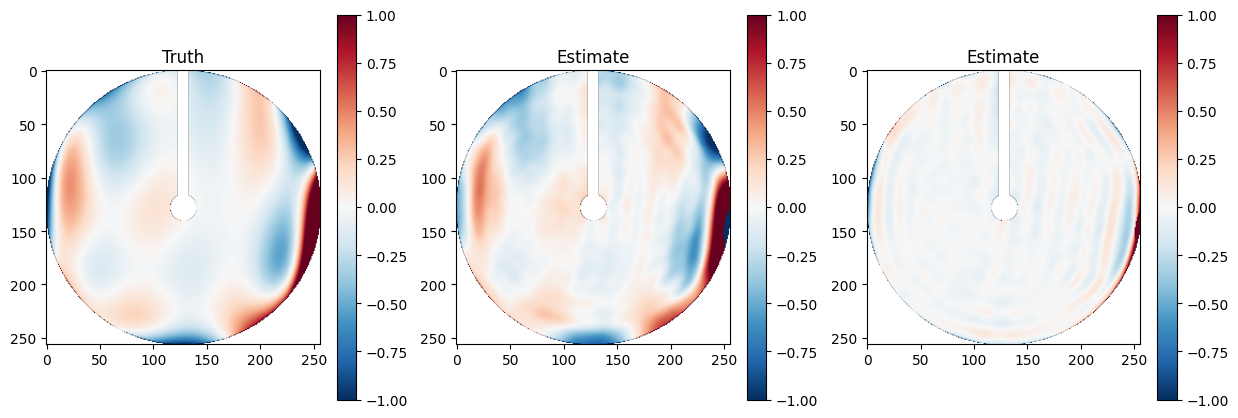

In [162]:
vlim = 1

wfe -= np.mean(wfe[pupil.data==1])
phase_est -= np.mean(phase_est[pupil.data==1])

plt.figure(figsize=[15, 5])
plt.subplot(131)
plt.title("Truth")
plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(132)
plt.title("Estimate")
plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(133)
plt.title("Estimate")
plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

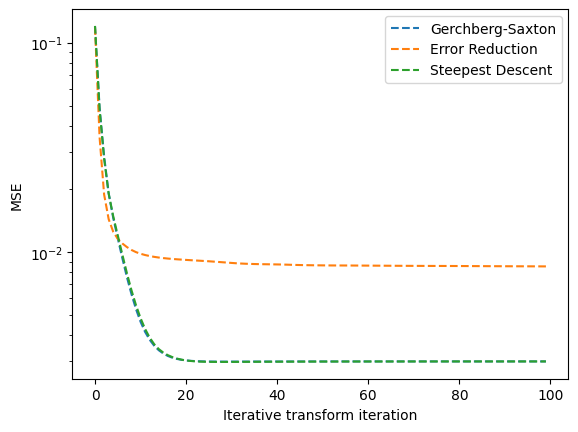

In [163]:
plt.figure()
plt.plot(gspr.cost, linestyle="dashed", label="Gerchberg-Saxton")
plt.plot(erpr.cost, linestyle="dashed", label="Error Reduction")
plt.plot(sdpr.cost, linestyle="dashed", label="Steepest Descent")
plt.ylabel("MSE")
plt.xlabel("Iterative transform iteration")
plt.yscale("log")
plt.legend()
plt.show()

## Conjugate Gradient

In [164]:
from dygdug.phase_retrieval import ConjugateGradient 

cgpr = ConjugateGradient(
    amp=pupil.data,
    wvl=0.5,
    executor=executor,
    data=np.abs(psf) ** 2,
    hk=1.0 
)

for _ in range(N_ITER):
    field_est = cgpr.step()
phase_est = np.angle(field_est)

/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:9: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
/var/folders/hc/vdwypdzx4rq1mm1_k3jv78_80000gn/T/ipykernel_46650/796667473.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)


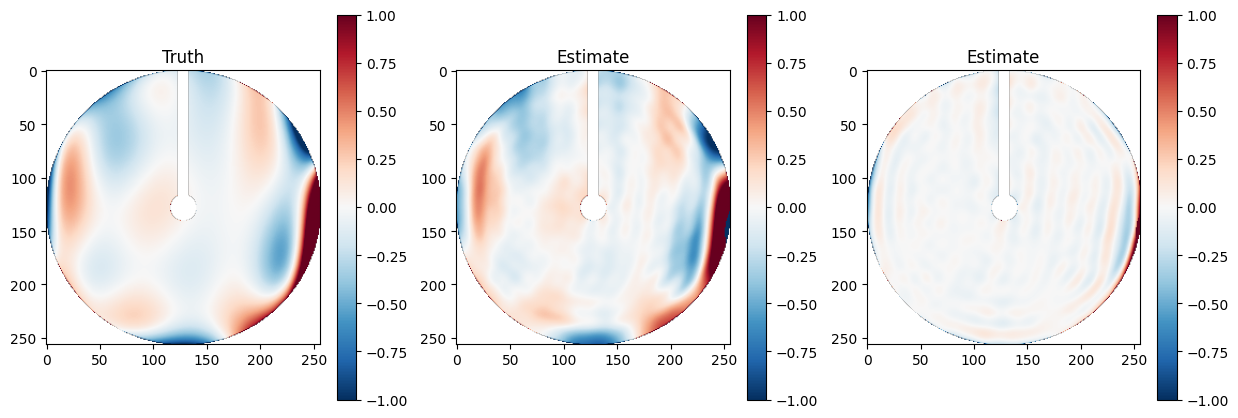

In [165]:
vlim = 1

wfe -= np.mean(wfe[pupil.data==1])
phase_est -= np.mean(phase_est[pupil.data==1])

plt.figure(figsize=[15, 5])
plt.subplot(131)
plt.title("Truth")
plt.imshow(wfe / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(132)
plt.title("Estimate")
plt.imshow(phase_est / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.subplot(133)
plt.title("Estimate")
plt.imshow((wfe - phase_est) / pupil.data, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
plt.colorbar()
plt.show()

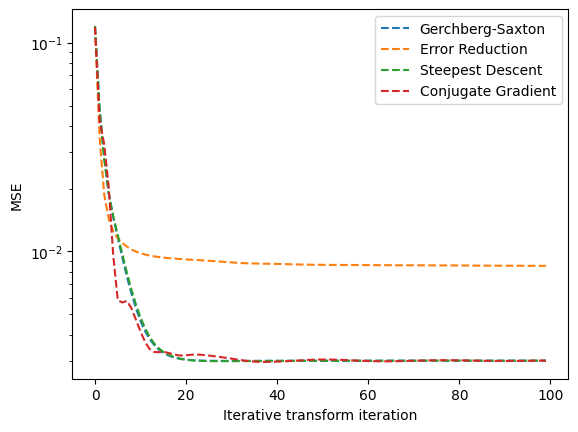

In [166]:
plt.figure()
plt.plot(gspr.cost, linestyle="dashed", label="Gerchberg-Saxton")
plt.plot(erpr.cost, linestyle="dashed", label="Error Reduction")
plt.plot(sdpr.cost, linestyle="dashed", label="Steepest Descent")
plt.plot(cgpr.cost, linestyle="dashed", label="Conjugate Gradient")
plt.ylabel("MSE")
plt.xlabel("Iterative transform iteration")
plt.yscale("log")
plt.legend()
plt.show()